In [1]:
import pandas as pd
import numpy as np

In [5]:
def safe_convert(col):
    col_cleaned = col.replace(',', '', regex=True)
    return pd.to_numeric(col_cleaned, errors='coerce')

setpt = pd.read_csv('setpoint_publish(in).csv')
setpt = setpt.apply(lambda col: safe_convert(col) if col.name != 'var' else col)
setpt



,var,opt_mean,opt_sig,drift_mean,drift_sig,excursion_mean,excursion_sig
0,x1,22.1,0.295,22.111,0.442,22.115,0.5900
1,x2,44.8,1.045,46.010,1.840,46.547,2.3270
2,x4,0.4,0.023,0.368,0.027,0.304,0.0670
3,x5,150000.0,8000.000,135000.000,9000.000,120000.000,16000.0000
4,x7,1206.0,48.240,1266.300,75.978,1266.300,88.6410
5,x8,87.0,5.220,91.176,6.686,107.880,12.2264
6,x9,454.0,19.673,456.270,22.814,599.280,69.9160
7,x17,5492.0,256.293,5526.050,349.983,5552.410,425.6850


In [33]:
number_of_wafers = 5000

def generate_normal_data(mean, std_dev, size=number_of_wafers, seed=None):
    return np.random.normal(loc=mean, scale=std_dev, size=size)

In [88]:
from scipy.stats import skewnorm

def generate_skewed_data(mean, sig, alpha, size=number_of_wafers):
    return skewnorm.rvs(a=alpha, loc=mean, scale=sig, size=number_of_wafers)

In [89]:
datasets = {}
for data_name in ["opt", "drift", "excursion"]:
    rows = []
    for var, mean, sig in zip(setpt['var'], setpt[f'{data_name}_mean'], setpt[f'{data_name}_sig']):
        if data_name=="excursion" and var in ["x4","x5"]:
            rows.append(generate_skewed_data(mean, sig, alpha=200))
        elif data_name=="excursion" and var=="x8":
            rows.append(generate_skewed_data(mean, sig, alpha=-100))
        elif data_name=="excursion" and var=="x9":
            rows.append(generate_skewed_data(mean, sig, alpha=-200))
        else:
            rows.append(generate_normal_data(mean, sig, seed=42))
    
    datasets[data_name] = pd.DataFrame(np.column_stack(rows), columns=setpt['var'])

In [90]:
opt_data = datasets['opt']
drift_data = datasets['drift']
exc_data = datasets['excursion']
exc_data.head()

var,x1,x2,x4,x5,x7,x8,x9,x17
0,23.112124,48.388843,0.322612,137099.609995,1294.403463,103.726431,511.556755,4987.667685
1,20.970079,47.219790,0.327006,126265.072448,1143.697104,84.976930,597.721153,5387.803918
2,21.559841,48.017844,0.321999,140041.419235,1406.058113,87.118722,579.053070,6053.787763
3,22.432278,45.131617,0.339730,132377.012032,1305.906642,97.905373,562.436531,5128.667705
4,22.763234,45.117029,0.331143,133193.720551,1233.405166,87.559264,572.656536,5309.387808


# Outcome 

In [91]:
opt_data['outcome'] = -( 4 * np.pi * opt_data['x1'] + (77 / 100) * (opt_data['x2'] ** 2) +
    58 * opt_data['x5'] * opt_data['x4'] - 890 * opt_data['x17'] + 33.5 * opt_data['x7'] ) / (8 * 10**5)


drift_data['outcome'] = (-( 4 * np.pi * drift_data['x1'] + (77 / 100) * (drift_data['x2'] ** 2) +
    58 * drift_data['x5'] * drift_data['x4'] - 890 * drift_data['x17'] + 33.5 * drift_data['x7'] ) / (8 * 10**5)) 
+ (19 * drift_data['x5'] * drift_data['x9'] * drift_data['x8'] / (10**11))

exc_data['outcome'] = (-( 4 * np.pi * exc_data['x1'] + (77 / 100) * (exc_data['x2'] ** 2) +
    58 * exc_data['x5'] * exc_data['x4'] - 890 * exc_data['x17'] + 33.5 * exc_data['x7'] ) / (8 * 10**5)) 
+ ((19 * exc_data['x5'] * exc_data['x9'] * exc_data['x8']) / (10**11)) 
+ ((0.8 * exc_data['x4'] * (exc_data['x5']**2) * exc_data['x17'] ) / (10**13))


0       2.419585
1       2.247107
2       3.058328
3       2.442609
4       2.495269
          ...   
4995    2.725922
4996    2.608157
4997    4.590731
4998    3.087397
4999    3.410985
Length: 5000, dtype: float64

In [92]:
opt_data.head()

var,x1,x2,x4,x5,x7,x8,x9,x17,outcome
0,22.109335,45.360135,0.461358,153010.436538,1237.002743,83.176222,471.355092,5692.479227,1.160789
1,22.414811,44.017610,0.387530,151508.698310,1258.352022,87.552754,458.220340,5499.716363,1.806752
2,21.449024,44.240409,0.427450,152731.220476,1225.111076,96.741679,459.023145,6014.887464,1.904885
3,21.749200,44.583046,0.407338,139447.498723,1215.039963,84.283650,424.210172,5418.517791,1.856801
4,22.409914,44.857175,0.441904,147222.638954,1268.026995,86.570140,469.562292,5661.199668,1.525975


In [93]:
drift_data.head()

var,x1,x2,x4,x5,x7,x8,x9,x17,outcome
0,21.624298,47.614139,0.394195,138951.107926,1248.275736,81.684014,459.223309,5473.188819,2.063025
1,22.176821,42.444226,0.397718,132717.350563,1255.708396,90.456374,467.402654,5965.203915,2.754775
2,21.439888,44.383242,0.330088,132637.078193,1208.480125,92.752951,465.100355,5717.684702,3.133896
3,22.363961,48.594461,0.341051,143369.296799,1366.450568,102.462443,425.008365,5050.417644,2.013769
4,22.430895,44.339190,0.375535,135922.220872,1312.860779,98.259669,463.655083,5172.887571,1.996955


In [94]:
exc_data.head()

var,x1,x2,x4,x5,x7,x8,x9,x17,outcome
0,23.112124,48.388843,0.322612,137099.609995,1294.403463,103.726431,511.556755,4987.667685,2.285284
1,20.970079,47.219790,0.327006,126265.072448,1143.697104,84.976930,597.721153,5387.803918,2.950081
2,21.559841,48.017844,0.321999,140041.419235,1406.058113,87.118722,579.053070,6053.787763,3.404150
3,22.432278,45.131617,0.339730,132377.012032,1305.906642,97.905373,562.436531,5128.667705,2.388141
4,22.763234,45.117029,0.331143,133193.720551,1233.405166,87.559264,572.656536,5309.387808,2.655032


In [95]:
opt_data.to_csv("data/opt_data.csv", index=None)
drift_data.to_csv("data/drift_data.csv", index=None)
exc_data.to_csv("data/excursion_data.csv", index=None)

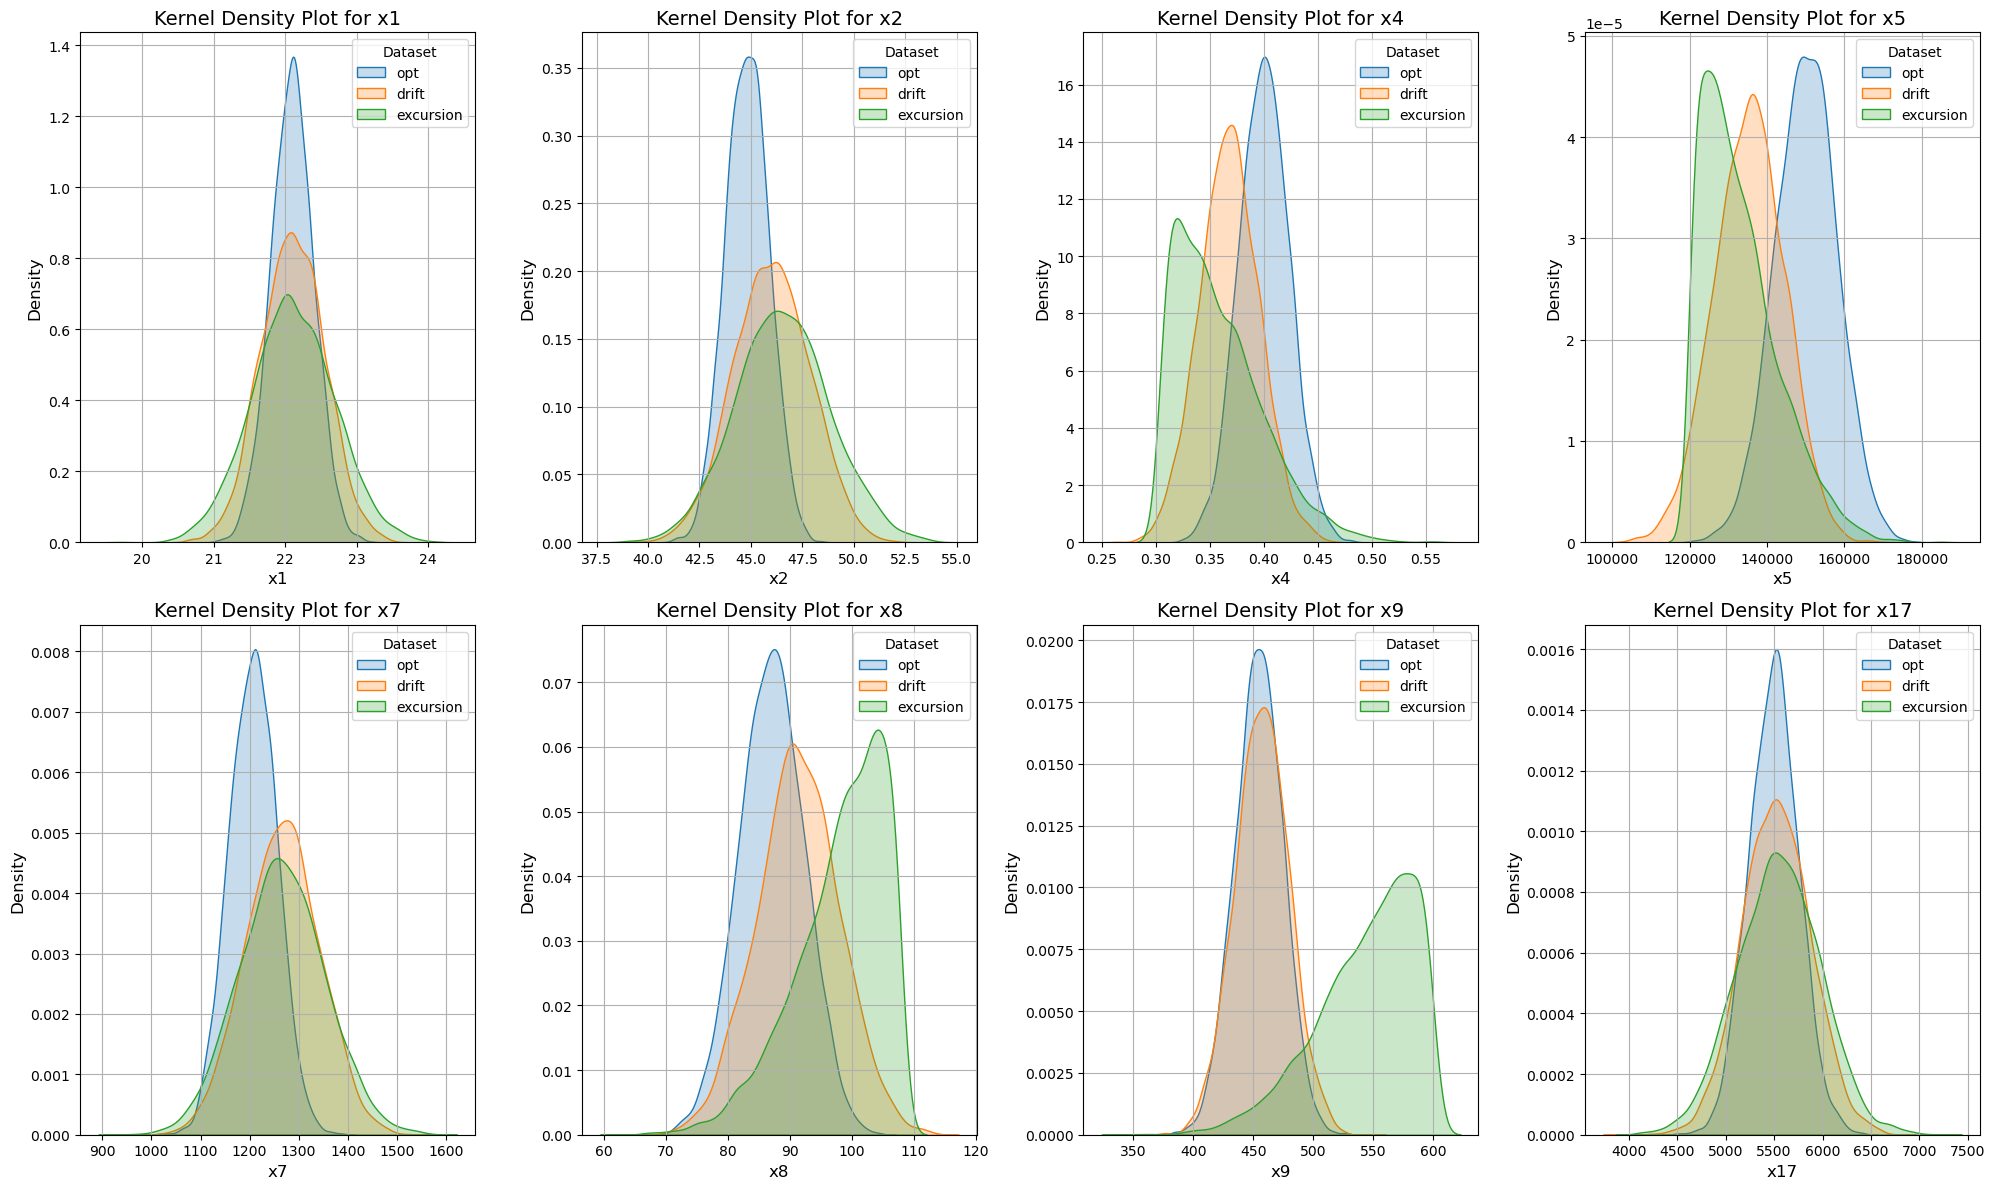

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datasets = {
    'opt': opt_data,
    'drift': drift_data,
    'excursion': exc_data
}

variables = opt_data.columns.drop('outcome') 

plots_per_row = 4

num_variables = len(variables)
num_rows = (num_variables + plots_per_row - 1) // plots_per_row 

fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(20, 6 * num_rows))
axes = axes.flatten()  

for i, variable in enumerate(variables):
    ax = axes[i]
    for name, df in datasets.items():
        sns.kdeplot(df[variable], label=name, fill=True, ax=ax)
    ax.set_title(f'Kernel Density Plot for {variable}', fontsize=14)
    ax.set_xlabel(variable, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(title='Dataset')
    ax.grid(True)

for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
